In [1]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
name = "productivity"
namex = "Productivity"
d = 11

###knn
graphsx = np.load("../graphs/"+name+"_knn_random.npy", allow_pickle=True)


## Info on the graphs

In [3]:
######
randomgraphsinfo = pd.read_csv("../graphs/productivity_knn_graphsummary.npy")
randomgraphsinfo


,Dataset (d),kmax,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Productivity (11),1,112,32,24,8,1.0,0.687500,0.312500,3.500000,0.040701,0.023488,0.017214,77,35,0,0,0
1,Productivity (11),2,112,44,33,11,2.0,1.455357,0.544643,5.090909,0.142375,0.096525,0.045849,62,11,0,0,1
2,Productivity (11),3,112,45,34,11,3.0,2.285714,0.714286,7.466667,0.294884,0.219916,0.074968,52,0,0,0,2
3,Productivity (11),4,112,46,35,11,4.0,2.946429,1.053571,9.739130,0.485199,0.335425,0.149775,28,0,0,0,3
4,Productivity (11),5,112,48,37,11,5.0,3.669643,1.330357,11.666667,0.738095,0.511422,0.226673,16,0,0,0,4
5,Productivity (11),6,112,48,37,11,6.0,4.401786,1.598214,14.000000,1.028958,0.712838,0.316120,9,0,0,0,5
6,Productivity (11),7,112,48,37,11,7.0,5.178571,1.821429,16.333333,1.351190,0.953668,0.397523,4,0,0,0,6
7,Productivity (11),8,112,48,37,11,8.0,6.017857,1.982143,18.666667,1.734878,1.267696,0.467181,3,0,0,0,7
8,Productivity (11),9,112,48,37,11,9.0,6.857143,2.142857,21.000000,2.141248,1.598295,0.542954,3,0,0,0,8
9,Productivity (11),10,112,48,37,11,10.0,7.642857,2.357143,23.333333,2.607143,1.949807,0.657336,2,0,0,0,9


## Compute and evaluate results for the targeted intervention model

In [4]:
summary_dfx = scripts.analytics.compute_itm_results(datasgraphs = graphsx,
                                                      thresh=False,
                                                      dsetname = name,
                                                      dsetdim = d)

summary_dfx.to_csv("./im_results/"+name+"_boost_results_knn.csv", index=False)
summary_dfx.head(10)

,K,B,Sg,Sg_lbls,F(Sg),Sgb,Sgb_lbls,F(Sgb)b4B,F(Sgb),Boostedgb,...,Boostedbg,usedBbudgetbg,kmax,n,m,greedyTime,greedyBoostTime,boostGreedyTime,dataset,graphid
0,1,4,{},{},77.0,{},{},77.0,81.0,"[0, 4, 5, 9]",...,"[0, 4, 5, 9]",4,1,112,32,0.022018,0.014869,0.011049,productivity (11),0
1,1,3,{},{},77.0,{},{},77.0,80.0,"[0, 4, 5]",...,"[0, 4, 5]",3,1,112,32,0.013481,0.012017,0.011437,productivity (11),0
2,1,2,{},{},77.0,{},{},77.0,79.0,"[0, 4]",...,"[0, 4]",2,1,112,32,0.011741,0.012430,0.013570,productivity (11),0
3,1,1,{},{},77.0,{},{},77.0,78.0,[0],...,[0],1,1,112,32,0.012681,0.012852,0.014454,productivity (11),0
4,1,0,{},{},77.0,{},{},77.0,77.0,[],...,[],0,1,112,32,0.012529,0.011858,0.012229,productivity (11),0
5,2,4,{},{},77.0,{},{},77.0,81.0,"[0, 4, 5, 9]",...,"[0, 4, 5, 9]",4,1,112,32,0.011653,0.013187,0.012509,productivity (11),0
6,2,3,{},{},77.0,{},{},77.0,80.0,"[0, 4, 5]",...,"[0, 4, 5]",3,1,112,32,0.011929,0.012330,0.011541,productivity (11),0
7,2,2,{},{},77.0,{},{},77.0,79.0,"[0, 4]",...,"[0, 4]",2,1,112,32,0.011971,0.012779,0.011964,productivity (11),0
8,2,1,{},{},77.0,{},{},77.0,78.0,[0],...,[0],1,1,112,32,0.010930,0.013320,0.013508,productivity (11),0
9,2,0,{},{},77.0,{},{},77.0,77.0,[],...,[],0,1,112,32,0.013846,0.012833,0.011909,productivity (11),0


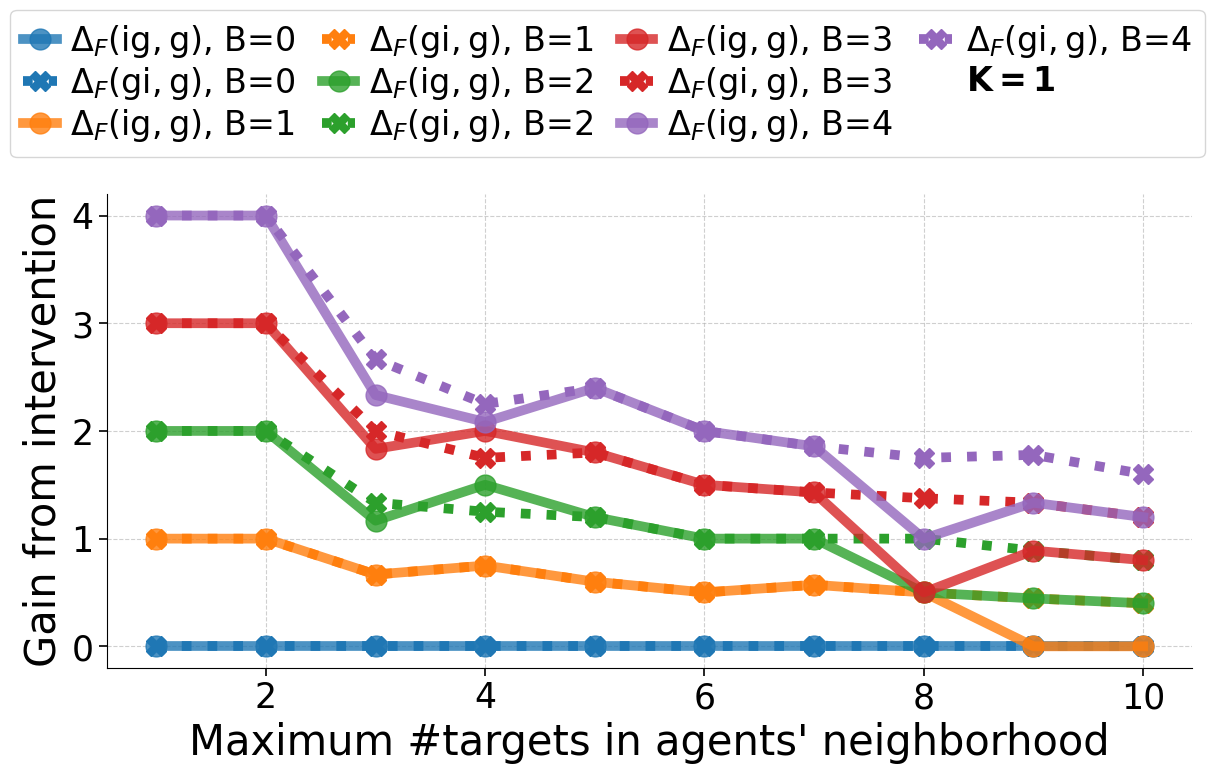

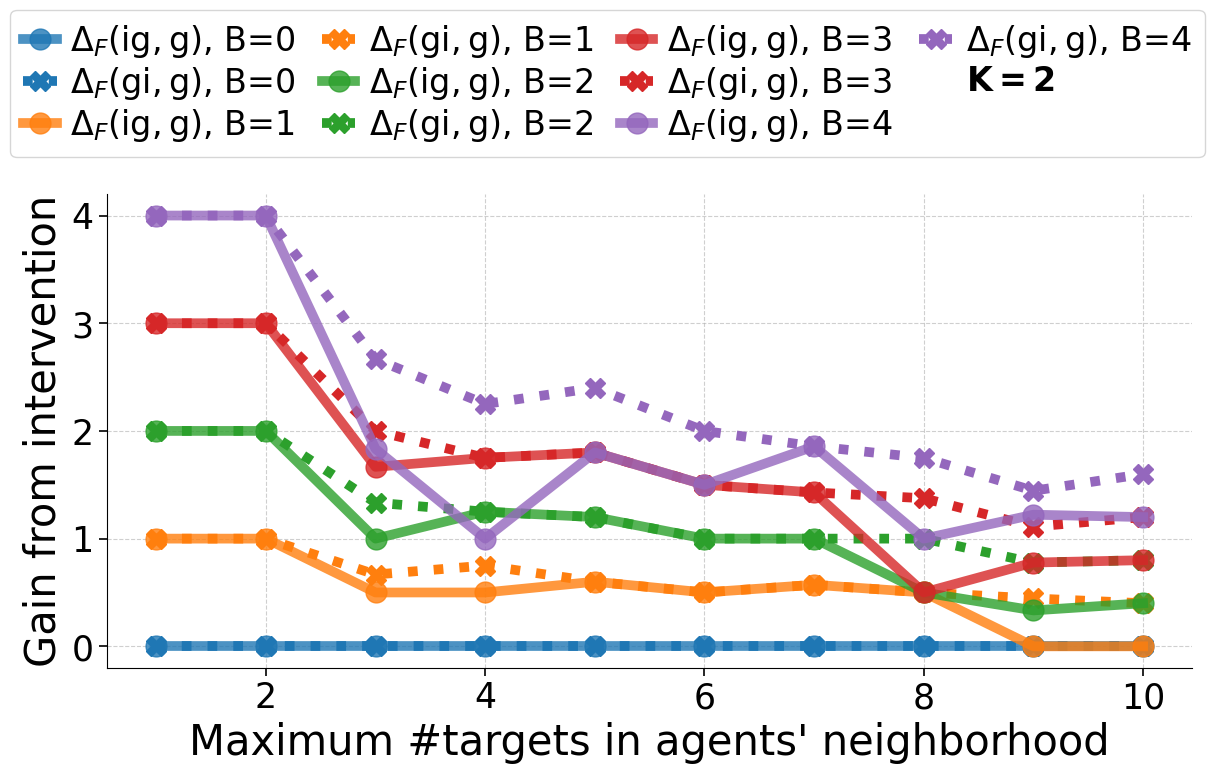

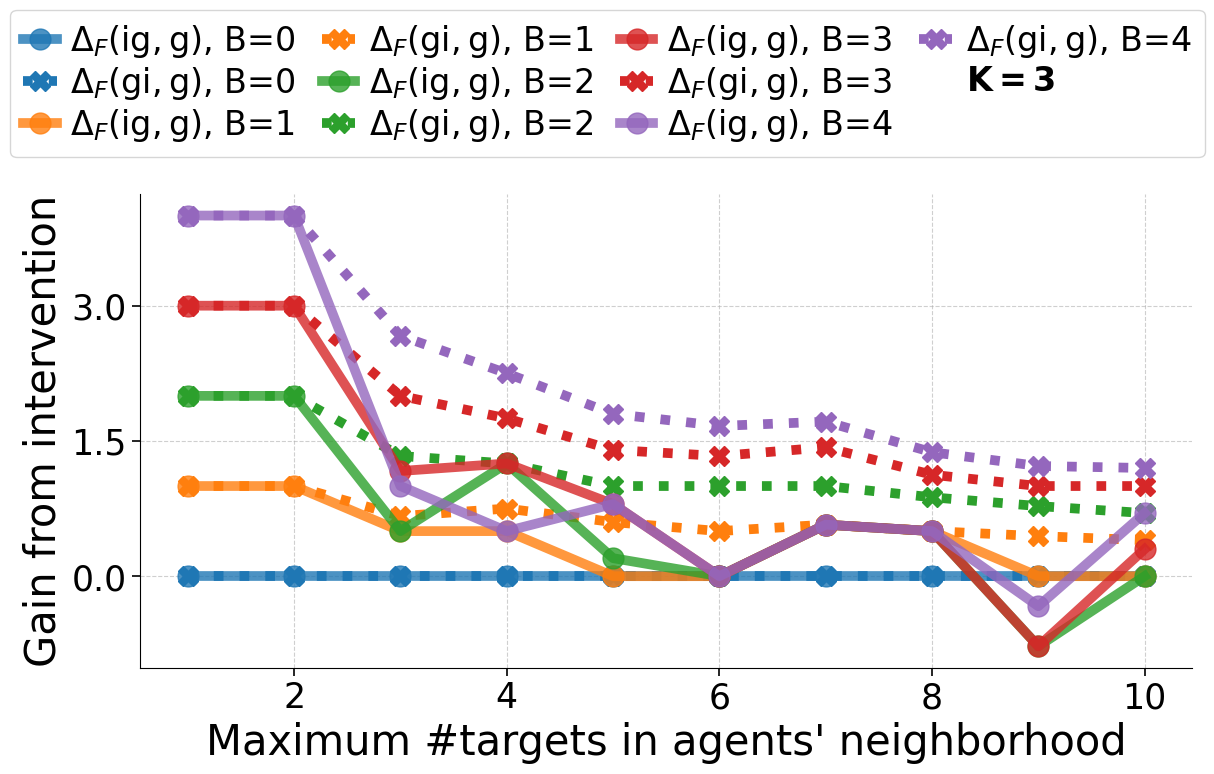

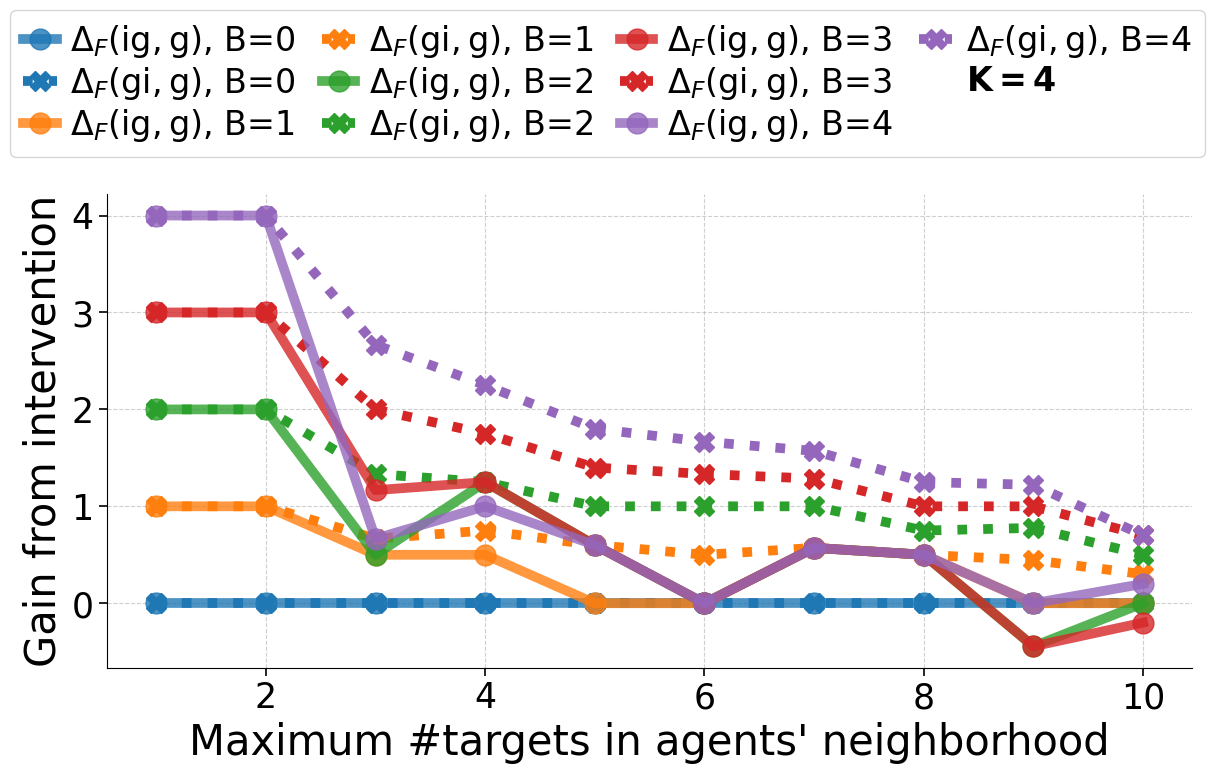

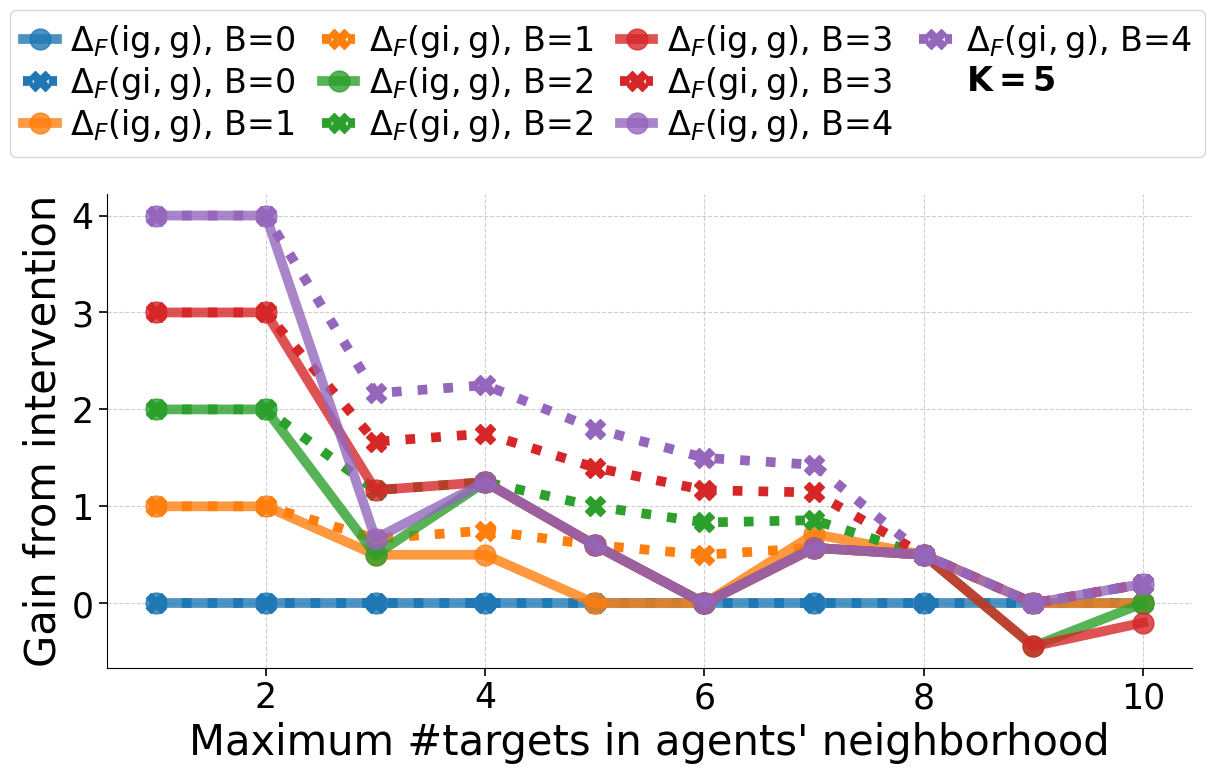

In [5]:
scripts.analytics.plot_intm_results(resdf = summary_dfx,
                                      thresh=False,
                                      save_as = "./im_results/figures/"+name+"_imb4aftersm_results_knn")